# Linear model
We'll train a linear model for images of 10 digits  
$ y = x * A + b $  
Assuming images 28x28x1 (grayscale), $x$ has dimensionality $28*28 = 784$  
$ x \in R^{784} $  - images  
$ y \in R^{10} $  - scores for each digit  
$ A \in R^{784x10} $  - linear transformation  
$ b \in R^{10} $ -  bias term

We want to find **A, b** that will assign a **high score** to the correct digit

In [40]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms


# PyTorch datasets
Default implementations available: https://pytorch.org/docs/stable/data.html  
For images: https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder  
**Dataset** must implement __getitem__(index) (returns indexed element) and __len__() (returns number of elements)  
Some datasets have an interface ready in `torchvision` package and are downloaded automatically

In [41]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    import torch_directml
    device = torch_directml.device()
except (ImportError, RuntimeError): 
    device = torch.device("cpu")

device

device(type='cpu')

**MNIST** dataset ready in https://pytorch.org/docs/stable/torchvision/datasets.html#mnist

In [42]:
from torchvision.datasets import MNIST
# Create MNIST dataset: images
# TODO download data

root_dir = './mnist'
dataset = MNIST(root=root_dir, train=True, download=True) #rn images are PIL images not tensors, to make them tensors you do transform=transforms.toTensor()

In [43]:
# TODO - print size of the data
len(dataset)

60000

dataset:  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./mnist
    Split: Train
dataset.data:  tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
    

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

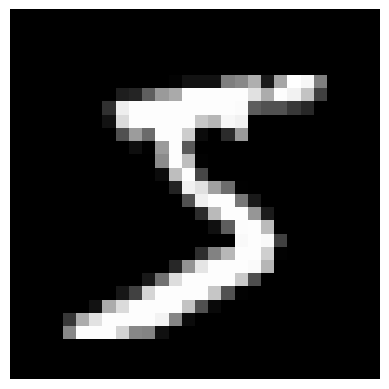

In [44]:
# TODO -  Show elements of dataset
print("dataset: " ,dataset)
print("dataset.data: " ,dataset.data)

img, label = dataset[0] #first data, access element by index
print("type(img): ", type(img))
print("label: " ,label)


#plot
plt.imshow(img,cmap="gray")
plt.axis("off")

In [45]:
# TODO -  Create MNIST dataset that transforms images to Tensors
#In PyTorch, tensors are generally structured as [Batch_Size, Channels, Height, Width] for images

#create it again but using transform to tensor:
data = MNIST(
    root=root_dir,
    train=True,
    download=True,
    transform=transforms.ToTensor(), #this only transforms the image to a tensor, not the label
    #target_transform=lambda y: torch.tensor(y, dtype=torch.float32)#so i added this (otherwise, we can just use CrossEntropyLoss(), for which the change isnt needed)

)

In [46]:
# TODO - show label and dimension of input tensors
print(type(data))
sample = data[0]
print(sample) #to understand how the dataset is formatted


img,label = data[0] #img is img_tensor
print(label)
print(img.shape)
#len(data) doesnt work for tensors

<class 'torchvision.datasets.mnist.MNIST'>
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0

**DataLoader** objects provide a way to efficiently iterate over datasets https://pytorch.org/docs/stable/data.html

In [47]:
from torch.utils.data import DataLoader
# TODO - define dataloader

dataloader = DataLoader(data, batch_size=10, shuffle=True, num_workers=4)


In [48]:
# TODO We can iterate over the dataset

#iteration over over batch
for images,labels in dataloader:
    print(images.shape)
    print(labels)
    break

 #iteration over all dataset
for batch_id, (images,labels) in enumerate(dataloader): #enum loops over and returns an enum object that produces pairs in the form (index, element)
    print("Batch: ",batch_id)
    print("images shape: ", images.shape)
    print("labels: ", labels)
    # this creates many batches of images
    
    #images shape:  torch.Size([10, 1, 28, 28]) 10 is batch_size, 1 is grayscale channel, 28x28 width x height

torch.Size([10, 1, 28, 28])
tensor([4, 6, 4, 6, 7, 9, 8, 2, 9, 5])
Batch:  0
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([3, 5, 6, 0, 1, 5, 3, 0, 6, 5])
Batch:  1
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([8, 1, 1, 8, 9, 9, 4, 8, 6, 5])
Batch:  2
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([7, 3, 6, 1, 3, 8, 4, 3, 2, 3])
Batch:  3
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([8, 8, 4, 8, 8, 5, 6, 5, 7, 6])
Batch:  4
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([5, 2, 4, 0, 3, 7, 3, 0, 7, 1])
Batch:  5
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([8, 6, 2, 7, 1, 5, 8, 4, 8, 8])
Batch:  6
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([6, 9, 2, 3, 2, 5, 8, 9, 8, 8])
Batch:  7
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([5, 6, 7, 0, 9, 7, 0, 5, 0, 8])
Batch:  8
images shape:  torch.Size([10, 1, 28, 28])
labels:  tensor([7, 8, 2, 1, 1, 2, 2, 7, 4, 0])
Batch:  9
images shape: 

## PyTorch models
Pytorch models are defined as **Module** objects that need to have a **forward** method implemented that applies transformations (neural network layers) on data. https://pytorch.org/docs/stable/nn.html

In [49]:
import torch.nn as nn
class LinearModel(nn.Module):
    
    def __init__(self, input_dim, n_classes): #input, output
        super(LinearModel, self).__init__()
        # TODO - define a linear model
        #linear layer expcets input like (batch_size, number_of_features), so we want (10,784)
        self.linear= nn.Linear(input_dim,n_classes)# linear layer: 784 → 10
        
        
    def forward(self, input):
        # TODO - apply linear model to input data
        input = input.view(input.size(0),-1 )# flatten images: (batch, 1, 28, 28) → (batch, 784)
        #input.size(0) returns the batch size; in Pytorch, -1 means "automatically infer this dimension"
        #.view() reshapes the tensor without copying data.
        output= self.linear(input)
        return output

        


In [50]:
# # TODO - Create model
model= LinearModel(28*28,10) #input from img_shape (nb of input features), output nb of classes


In [51]:
from utils import train_mse,train #we implemented those

# we dont use MSE bcz it assumes that “distance between numbers matters” but in MNIST class 9 is not bigger than class1
# TODO - train the model

train(dataloader,model, n_epochs=10, device=device, loss_fn=nn.CrossEntropyLoss(),optimizer=torch.optim.SGD(model.parameters(), 0.001))

  0%|          | 0/10 [00:00<?, ?it/s]

In [52]:
print(model.linear.weight)


Parameter containing:
tensor([[ 0.0092,  0.0186, -0.0056,  ...,  0.0108, -0.0015, -0.0189],
        [-0.0014,  0.0237,  0.0026,  ...,  0.0052, -0.0081, -0.0190],
        [ 0.0080, -0.0093,  0.0300,  ..., -0.0176, -0.0062, -0.0267],
        ...,
        [-0.0248,  0.0186, -0.0339,  ..., -0.0270, -0.0154,  0.0308],
        [-0.0324, -0.0011, -0.0008,  ...,  0.0046, -0.0221,  0.0099],
        [-0.0036, -0.0013, -0.0091,  ..., -0.0234,  0.0239, -0.0008]],
       requires_grad=True)


In [53]:
# TODO - load test data

test_data= MNIST(
    root=root_dir,
    train=False,
    download=False,
    transform= transforms.ToTensor()
    
)
test_dataloader = DataLoader(test_data, batch_size=10, shuffle=True, num_workers=0)

In [ ]:
# Write a fucntion that evaluates the model
'''1.Loop over the test data
2. Get model predictions
3. Compare with true labels
4. Compute accuracy
'''
#accuracy is (number of correct predictions) / (total samples)
from torch import argmax


def calculate_accuracy(dataloader, model):
    correct = 0
    total = 0
    for images,labels in dataloader:
        images= images.view(images.size(0),-1) #flatten image, important for MNIST
        outputs= model(images) #generate predictions with the model we created, on the data that we loaded in the dataloader
        preds= argmax(outputs, dim=1) #argmax returns the index of the largest value, dim=1 goes row by row. If u dont specify dim , it will give u global max in the entire matrix but u dont want just one number
        correct += (preds == labels).sum().item() #item() converts tensor back to number for the math operations to work (sum)
        total+= labels.size(0)
        

    accuracy = 100 * correct / total
    print(accuracy, "%")
    
    return accuracy

90.42 %


90.42

In [55]:
import numpy as np
accuracy = calculate_accuracy(test_dataloader, model)
# TODO - Print accuracy on test data
print('Test accuracy: {:.2f}%'.format(accuracy))

90.42 %
Test accuracy: 90.42%


In [56]:
train_accuracy = calculate_accuracy(dataloader, model)
# TODO - Print accuracy on train data
print('Train accuracy: {:.2f}%'.format(train_accuracy))

89.7 %
Train accuracy: 89.70%
